# Bofedal Panel — Exploratory Data Analysis

Stage 3 output: `Data/bofedal_panel.parquet` — one row per **(bofedal, year)**,
the outcome + climate side of the Methodology-v2 causal panel. The *treatment*
columns (pond/well distances) are the Stage 2 deliverable and are **not yet joined**.

This notebook is a quick tour of what the panel contains and how it behaves.

**Run:** `uv run jupyter lab notebooks/panel_eda.ipynb` (needs the `notebook` extra).


In [2]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Resolve repo root whether run from notebooks/ or repo root.
ROOT = Path.cwd()
if not (ROOT / "Data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "Data"

MEGA_DROUGHT = (2010, 2018)  # Garreaud et al. 2020
print("repo root:", ROOT)

repo root: /Users/santi/Lithium


## 1. Load

In [5]:
panel = pd.read_parquet(DATA / "bofedal_panel.parquet")
bofedales = gpd.read_file(DATA / "bofedales_v2.geojson")

print(f"panel:      {panel.shape[0]:,} rows  x  {panel.shape[1]} cols")
print(f"bofedales:  {len(bofedales):,} polygons")
print(f"years:      {panel.year.min()}–{panel.year.max()}  "
      f"({panel.year.nunique()} yrs)  x  {panel.bofedal_id.nunique():,} bofedales")
panel.head()

panel:      103,167 rows  x  14 cols
bofedales:  3,821 polygons
years:      1998–2024  (27 yrs)  x  3,821 bofedales


,bofedal_id,year,ndvi_gs_median,ndvi_gs_n_obs,ndvi_annual_median,ndvi_annual_n_obs,s1_vv_db_median,s1_vh_db_median,s1_n_obs,spei_12_gs_mean,spei_24_gs_mean,elevation_m,containing_salar,mega_drought_dummy
0,f74a42b1-6e00-5388-a18e-6ead765df8c4,1998,0.170114,16,0.130769,16,NaN,NaN,<NA>,-0.549803,-0.320857,3694.85791,<NA>,0
1,f74a42b1-6e00-5388-a18e-6ead765df8c4,1999,0.113921,16,0.130520,16,NaN,NaN,<NA>,0.273115,-0.224972,3694.85791,<NA>,0
2,f74a42b1-6e00-5388-a18e-6ead765df8c4,2000,0.201370,16,0.132950,16,NaN,NaN,<NA>,0.840275,0.647325,3694.85791,<NA>,0
3,f74a42b1-6e00-5388-a18e-6ead765df8c4,2001,0.302402,16,0.180315,16,NaN,NaN,<NA>,1.601984,1.452057,3694.85791,<NA>,0
4,f74a42b1-6e00-5388-a18e-6ead765df8c4,2002,0.381997,16,0.197903,16,NaN,NaN,<NA>,0.329935,1.204703,3694.85791,<NA>,0


In [6]:
panel

,bofedal_id,year,ndvi_gs_median,ndvi_gs_n_obs,ndvi_annual_median,ndvi_annual_n_obs,s1_vv_db_median,s1_vh_db_median,s1_n_obs,spei_12_gs_mean,spei_24_gs_mean,elevation_m,containing_salar,mega_drought_dummy
0,f74a42b1-6e00-5388-a18e-6ead765df8c4,1998,0.170114,16,0.130769,16,NaN,NaN,<NA>,-0.549803,-0.320857,3694.857910,<NA>,0
1,f74a42b1-6e00-5388-a18e-6ead765df8c4,1999,0.113921,16,0.130520,16,NaN,NaN,<NA>,0.273115,-0.224972,3694.857910,<NA>,0
2,f74a42b1-6e00-5388-a18e-6ead765df8c4,2000,0.201370,16,0.132950,16,NaN,NaN,<NA>,0.840275,0.647325,3694.857910,<NA>,0
3,f74a42b1-6e00-5388-a18e-6ead765df8c4,2001,0.302402,16,0.180315,16,NaN,NaN,<NA>,1.601984,1.452057,3694.857910,<NA>,0
4,f74a42b1-6e00-5388-a18e-6ead765df8c4,2002,0.381997,16,0.197903,16,NaN,NaN,<NA>,0.329935,1.204703,3694.857910,<NA>,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103162,34cdd600-e0b4-5668-b024-66361c4df3b1,2020,0.656404,17,0.424713,17,-13.656612,-23.859131,17,0.855209,0.855855,4557.222656,<NA>,0
103163,34cdd600-e0b4-5668-b024-66361c4df3b1,2021,0.542888,17,0.370027,17,-13.507167,-23.532503,17,-1.084288,-0.066161,4557.222656,<NA>,0
103164,34cdd600-e0b4-5668-b024-66361c4df3b1,2022,0.674216,17,0.267565,17,NaN,NaN,0,0.003903,-0.651456,4557.222656,<NA>,0
103165,34cdd600-e0b4-5668-b024-66361c4df3b1,2023,0.677370,17,0.497578,17,NaN,NaN,0,-1.295575,-0.799376,4557.222656,<NA>,0


## 2. Column coverage
How much of each column is actually populated. Sentinel-1 only exists from 2014, so its low fill is expected; `containing_salar` is sparse because bofedales are basin-*margin* peatlands that mostly sit outside the salar polygons.

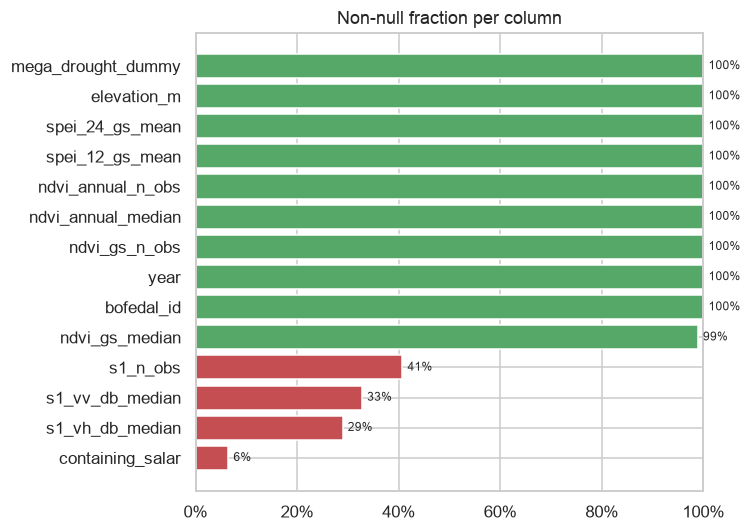

In [3]:
valid = panel.notna().mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#c44e52" if v < 0.5 else "#55a868" for v in valid]
ax.barh(valid.index, valid.values, color=colors)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.set_title("Non-null fraction per column")
for y, v in enumerate(valid.values):
    ax.text(v + 0.01, y, f"{v:.0%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Data density over time
Valid-pixel counts per bofedal reveal the Landsat sensor history (L5 ends 2013, L7 SLC-off after 2003, L8 from 2013, L9 from 2021) and the Sentinel-1 start in 2014.

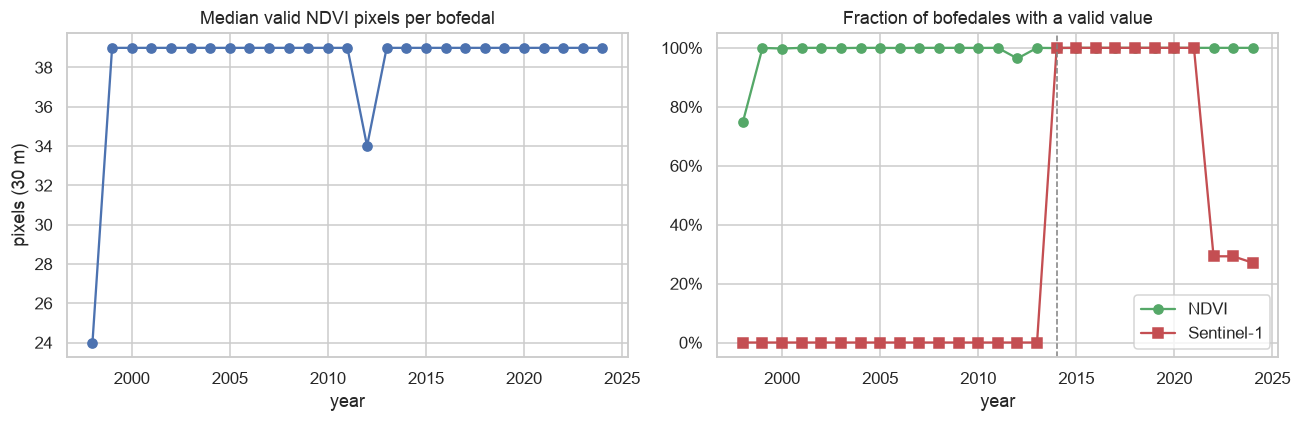

In [4]:
by_year = panel.groupby("year").agg(
    ndvi_valid=("ndvi_gs_median", lambda s: s.notna().mean()),
    ndvi_nobs=("ndvi_gs_n_obs", "median"),
    s1_valid=("s1_vv_db_median", lambda s: s.notna().mean()),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(by_year.index, by_year.ndvi_nobs, marker="o", color="#4c72b0")
ax1.set_title("Median valid NDVI pixels per bofedal")
ax1.set_xlabel("year"); ax1.set_ylabel("pixels (30 m)")

ax2.plot(by_year.index, by_year.ndvi_valid, marker="o", label="NDVI", color="#55a868")
ax2.plot(by_year.index, by_year.s1_valid, marker="s", label="Sentinel-1", color="#c44e52")
ax2.axvline(2014, ls="--", c="grey", lw=1)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_title("Fraction of bofedales with a valid value")
ax2.set_xlabel("year"); ax2.legend()
plt.tight_layout(); plt.show()

## 4. NDVI through time
Growing-season (Dec–Feb) NDVI averaged across all bofedales, with the 2010–2018 Andean mega-drought shaded. The band is the 25th–75th percentile across bofedales.

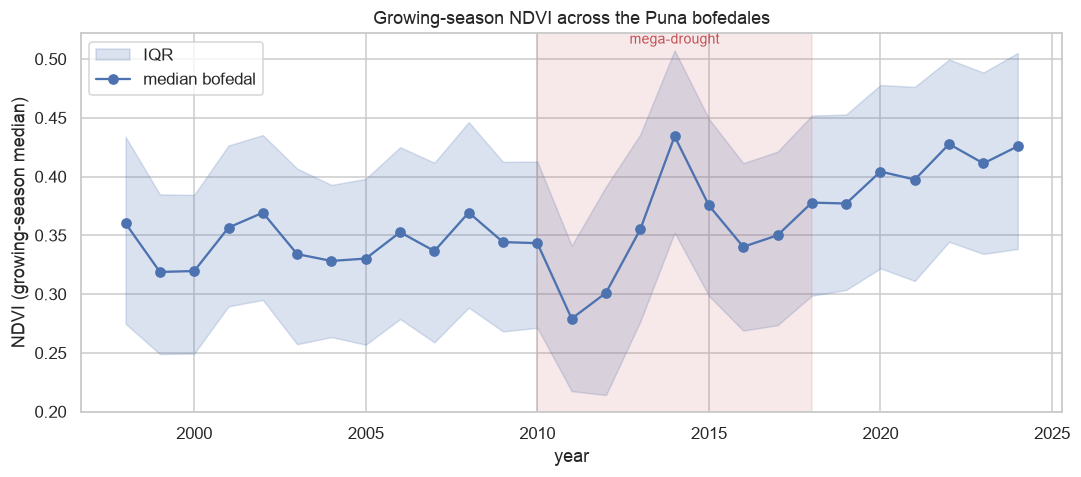

In [5]:
q = panel.groupby("year")["ndvi_gs_median"].quantile([.25, .5, .75]).unstack()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(q.index, q[.25], q[.75], alpha=.2, color="#4c72b0", label="IQR")
ax.plot(q.index, q[.5], marker="o", color="#4c72b0", label="median bofedal")
ax.axvspan(*MEGA_DROUGHT, alpha=.12, color="#c44e52")
ax.text(np.mean(MEGA_DROUGHT), ax.get_ylim()[1], "mega-drought",
        ha="center", va="top", fontsize=9, color="#c44e52")
ax.set_title("Growing-season NDVI across the Puna bofedales")
ax.set_xlabel("year"); ax.set_ylabel("NDVI (growing-season median)")
ax.legend(); plt.tight_layout(); plt.show()

## 5. NDVI distribution & climate coupling
Left: the spread of growing-season NDVI. Right: NDVI vs SPEI-24 (long-window drought index). Notably the **pooled contemporaneous correlation is near zero** (r ≈ −0.09) and the binned mean is nearly flat — bofedal NDVI does *not* track same-year SPEI in a simple linear way. That is itself informative: it is consistent with the Moran–Corkran picture where these peatlands are fed by old/relic groundwater and are **buffered against short-term climate**, so any climate signal is likely lagged and/or masked by fixed cross-bofedal differences. Stage 4 conditions on SPEI *within* bofedal (fixed effects) rather than relying on this pooled cross-section.

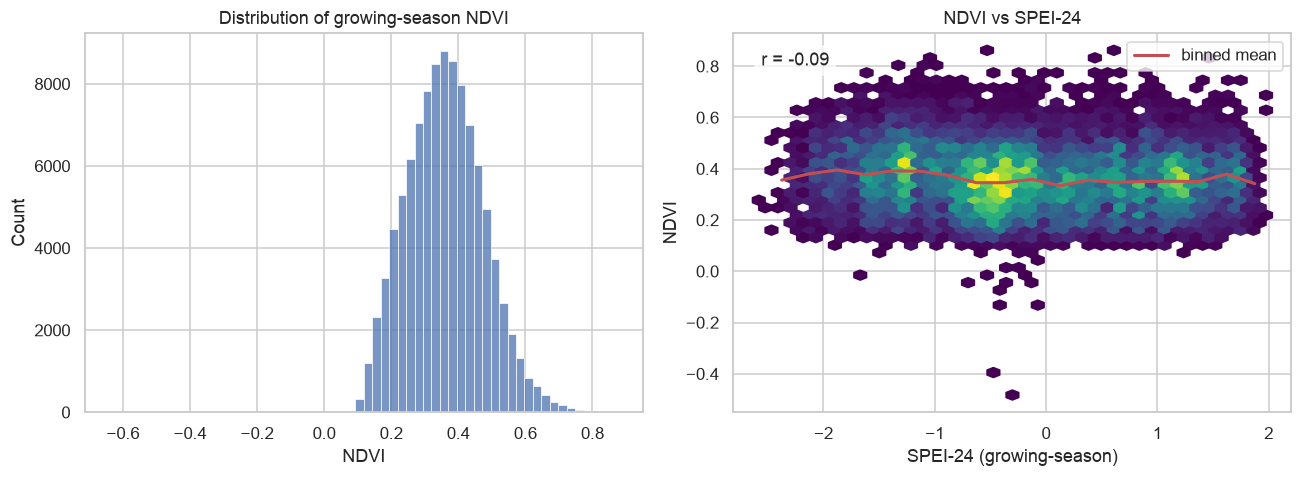

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(panel["ndvi_gs_median"].dropna(), bins=60, ax=ax1, color="#4c72b0")
ax1.set_title("Distribution of growing-season NDVI")
ax1.set_xlabel("NDVI")

samp = panel.dropna(subset=["ndvi_gs_median", "spei_24_gs_mean"]).sample(
    min(20000, len(panel)), random_state=0)
ax2.hexbin(samp["spei_24_gs_mean"], samp["ndvi_gs_median"],
           gridsize=40, cmap="viridis", mincnt=1)
# binned mean overlay
bins = pd.cut(panel["spei_24_gs_mean"], np.linspace(-2.5, 2.5, 21))
bm = panel.groupby(bins, observed=True)["ndvi_gs_median"].mean()
centers = [i.mid for i in bm.index]
ax2.plot(centers, bm.values, color="#c44e52", lw=2, label="binned mean")
ax2.set_title("NDVI vs SPEI-24"); ax2.set_xlabel("SPEI-24 (growing-season)")
ax2.set_ylabel("NDVI"); ax2.legend()
r = samp["spei_24_gs_mean"].corr(samp["ndvi_gs_median"])
ax2.text(.05, .95, f"r = {r:.2f}", transform=ax2.transAxes, va="top",
         bbox=dict(fc="white", alpha=.7))
plt.tight_layout(); plt.show()

## 6. Bofedal size & elevation
The analysis units themselves: most bofedales are small (median a few hectares), sitting on the high Puna plateau.

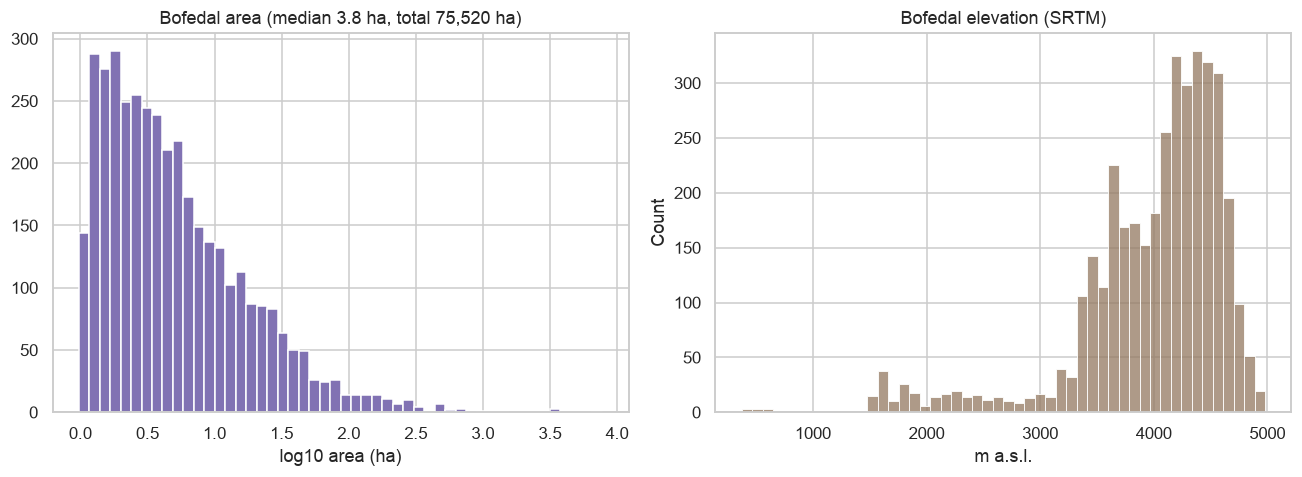

In [7]:
bof = bofedales.to_crs(3857)
bof["area_ha"] = bof.area / 1e4
elev = panel.drop_duplicates("bofedal_id")[["bofedal_id", "elevation_m"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.hist(np.log10(bof["area_ha"].clip(lower=.1)), bins=50, color="#8172b3")
ax1.set_title(f"Bofedal area (median {bof.area_ha.median():.1f} ha, "
              f"total {bof.area_ha.sum():,.0f} ha)")
ax1.set_xlabel("log10 area (ha)")

sns.histplot(elev["elevation_m"].dropna(), bins=50, ax=ax2, color="#937860")
ax2.set_title("Bofedal elevation (SRTM)")
ax2.set_xlabel("m a.s.l.")
plt.tight_layout(); plt.show()

## 7. Where the bofedales are — and the mining anchors
Bofedal centroids coloured by mean growing-season NDVI, with the 10 USGS lithium facilities (the Stage 2 backbone) overlaid. The facilities cluster in the same salars where bofedales concentrate — which is exactly why the causal design needs distance-based treatment rather than a basin-level label.

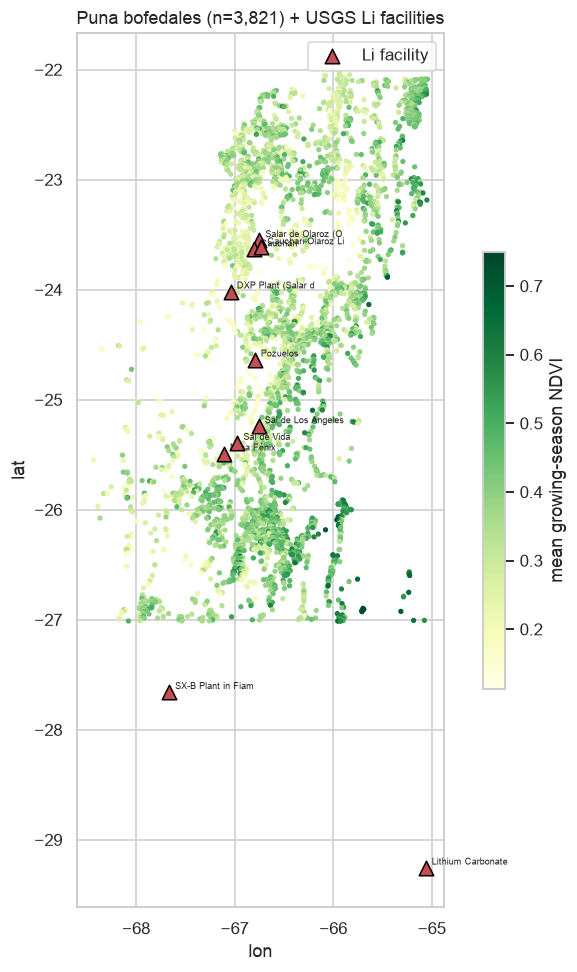

In [8]:
# Mean NDVI per bofedal, joined back to geometry centroids
mean_ndvi = panel.groupby("bofedal_id")["ndvi_gs_median"].mean().rename("mean_ndvi")
cent = bofedales[["bofedal_id", "geometry"]].copy()
cent["geometry"] = cent.geometry.centroid
cent = cent.merge(mean_ndvi, on="bofedal_id", how="left")

# USGS facilities
gdb = DATA / "external/usgs/extracted/Li_Triangle_ARG_MRP_NMIC.gdb"
facilities = None
try:
    facilities = gpd.read_file(gdb, layer="Arg_Facilities_MRP_NMIC").to_crs(4326)
except Exception as e:
    print("facilities layer unavailable:", e)

fig, ax = plt.subplots(figsize=(7.5, 9))
cent.plot(ax=ax, column="mean_ndvi", cmap="YlGn", markersize=6,
          legend=True, legend_kwds={"label": "mean growing-season NDVI",
                                    "shrink": .5})
if facilities is not None:
    facilities.plot(ax=ax, color="#c44e52", marker="^", markersize=90,
                    edgecolor="black", zorder=5, label="Li facility")
    for _, r in facilities.iterrows():
        ax.annotate(r["Project"][:18], (r.geometry.x, r.geometry.y),
                    fontsize=6, xytext=(4, 2), textcoords="offset points")
    ax.legend(loc="upper right")
ax.set_title("Puna bofedales (n=3,821) + USGS Li facilities")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.tight_layout(); plt.show()

## 8. A treatment teaser — NDVI trajectories by salar
Growing-season NDVI for the salars that host lithium operations vs. the panel-wide median. This is *descriptive only* — no controls, no climate conditioning — but it previews the kind of divergence Stage 4 will test formally once Stage 2 supplies the pond/well distances.

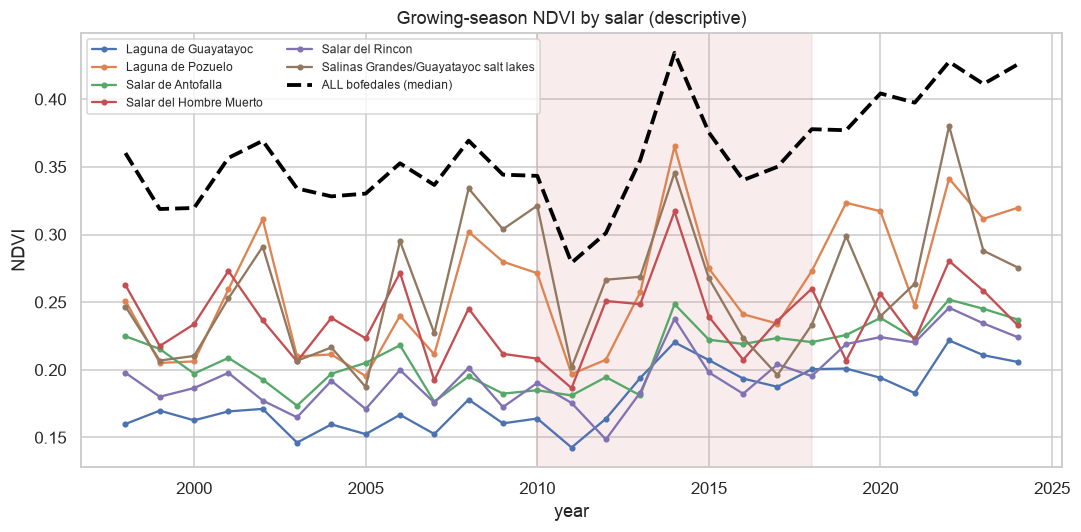

In [9]:
labelled = panel.dropna(subset=["containing_salar"])
top_salars = labelled["containing_salar"].value_counts().head(6).index
sub = labelled[labelled["containing_salar"].isin(top_salars)]

traj = sub.groupby(["containing_salar", "year"])["ndvi_gs_median"].median().reset_index()
overall = panel.groupby("year")["ndvi_gs_median"].median()

fig, ax = plt.subplots(figsize=(10, 5))
for name, g in traj.groupby("containing_salar"):
    ax.plot(g.year, g.ndvi_gs_median, marker=".", label=name)
ax.plot(overall.index, overall.values, color="black", lw=2.5,
        ls="--", label="ALL bofedales (median)")
ax.axvspan(*MEGA_DROUGHT, alpha=.10, color="#c44e52")
ax.set_title("Growing-season NDVI by salar (descriptive)")
ax.set_xlabel("year"); ax.set_ylabel("NDVI")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## Takeaways

- **103,167 rows**, 3,821 bofedales × 27 years (1998–2024); NDVI ~99% complete, Sentinel-1 from 2014 on.
- The **pooled** NDVI–SPEI correlation is near zero (r ≈ −0.09) — bofedales look buffered against contemporaneous climate (Moran–Corkran). The climate signal is likely lagged / within-unit, which is exactly why Stage 4 uses bofedal fixed effects and conditions on SPEI rather than trusting a raw cross-section.
- Bofedales are small (median ~4 ha) and sit *next to*, not inside, the salars — so **distance-based treatment** is the right design.
- **Missing:** the Stage 2 treatment columns (`pond_dist_m`, `pond_area_m2`, `brine_dist_m`, `fresh_dist_m`, `years_since_mine`). Once joined on `bofedal_id`, this panel feeds Stage 4 (CS-DiD + spatial RDD).